
# 02 — Mini N-body example with spectra

Run a tiny PM evolution, produce density snapshots, and inspect their spectra.


In [1]:

import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")


'cpu'

In [2]:

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np

from fwd_model_tools import gaussian_initial_conditions
from fwd_model_tools.pm import lpt, nbody
from fwd_model_tools.power import angular_cl_flat, power


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


ERROR:2025-11-25 02:34:55,743:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_OPERATING_SYSTEM


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [3]:

# Small configuration for speed
key = jax.random.PRNGKey(1)
mesh_size = (16, 16, 16)
box_size = (200.0, 200.0, 200.0)
flatsky_npix = (48, 48)
cosmo = jc.Planck15()

pk_fn = lambda k: 1.0 / (1.0 + (k / 0.15) ** 3)


In [4]:

# 1) Initial conditions and LPT
init_field = gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    pk_fn=pk_fn,
    cosmo=cosmo,
    flatsky_npix=flatsky_npix,
)

# First-order LPT at early time
start_a = 0.1
dx_field, p_field = lpt(cosmo, init_field, a=start_a, order=1)
print(dx_field)


shape of initial force: (16, 16, 16, 3)
growth factor shape: (1,)


ParticleField(array=Array(16, 16, 16, 3), mesh_size=(16, 16, 16), box_size=(200.0, 200.0, 200.0), status=lpt1, scale_factors_shape=(1,))


In [5]:

# 2) Short N-body run to z=0 producing 3D density snapshots
lightcone_density = nbody(
    cosmo,
    dx_field,
    p_field,
    t1=1.0,
    dt0=0.1,
    nb_shells=2,
    geometry="density",
)
print(lightcone_density)


DensityField(array=Array(2, 16, 16, 16), mesh_size=(16, 16, 16), box_size=(200.0, 200.0, 200.0), status=density_field, scale_factors_shape=(2,))


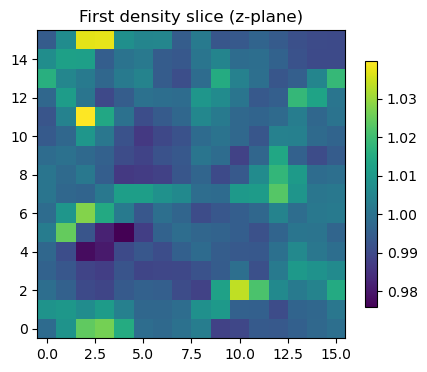

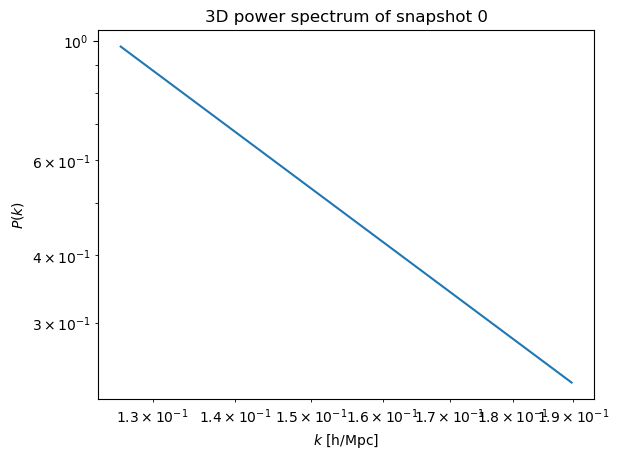

In [6]:

# 3) Inspect the first density snapshot and its 3D power spectrum
first_density = np.asarray(lightcone_density.array[0])
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(first_density[:, :, -1], origin="lower")
ax.set_title("First density slice (z-plane)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

k, pk = power(first_density, box_shape=box_size)
plt.loglog(np.asarray(k), np.asarray(pk))
plt.xlabel(r"$k$ [h/Mpc]")
plt.ylabel(r"$P(k)$")
plt.title("3D power spectrum of snapshot 0")
plt.show()


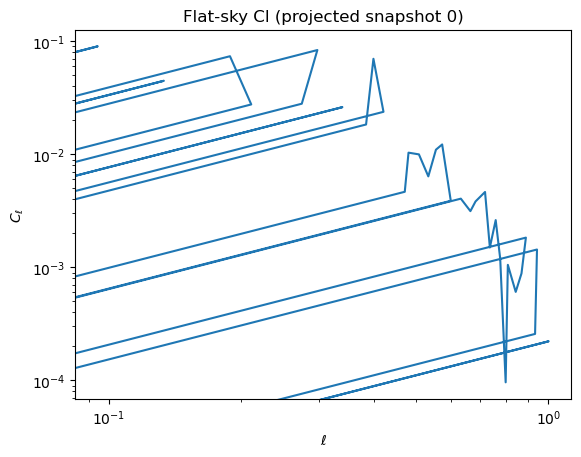

In [7]:

# 4) Flat projection of the same snapshot and its angular Cl
flat_proj = lightcone_density[0].project(nz_slices=4)
pixel_size = box_size[0] / flatsky_npix[0]
ell, cl = angular_cl_flat(np.asarray(flat_proj.array), pixel_size=pixel_size)

plt.loglog(np.asarray(ell[1:]), np.asarray(cl[1:]))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.title("Flat-sky Cl (projected snapshot 0)")
plt.show()



**Notes**
- Mesh and timestep choices are minimal; increase resolution and steps for realistic runs.
- The lightcone holds two snapshots; adjust `nb_shells` for more outputs.
